In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import pyro
import pyro.distributions as dist
from pyro.nn import PyroModule, PyroSample
import torch.nn as nn
from pyro.infer import Predictive

###PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

###Forward and Backward Selection
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
import statsmodels.api as sm

# HMC
from pyro.infer import MCMC, NUTS

# variational inference
from pyro.infer import SVI, Trace_ELBO
from pyro.infer.autoguide import AutoDiagonalNormal, AutoMultivariateNormal
from tqdm.auto import trange

import matplotlib as mpl
import os
import sys
import math

In [2]:
sys.path.append(
    r"C:\Users\thumo\OneDrive - Georgia Institute of Technology\Georgia Tech\Semesters\Spring 2025\CSE 8803 IUQ\Project\2-BNN_trained_prior\you-need-a-good-prior"
)

In [3]:
from optbnn.gp.models.gpr import GPR
from optbnn.gp import kernels, mean_functions, priors
from optbnn.bnn.reparam_nets import GaussianMLPReparameterization
from optbnn.bnn.nets.mlp import MLP
from optbnn.bnn.likelihoods import LikGaussian
from optbnn.bnn.priors import FixedGaussianPrior, OptimGaussianPrior
from optbnn.prior_mappers.wasserstein_mapper import MapperWasserstein, WassersteinDistance
from optbnn.utils.rand_generators import MeasureSetGenerator, GridGenerator
from optbnn.utils.normalization import normalize_data
from optbnn.utils.exp_utils import get_input_range
from optbnn.metrics.sampling import compute_rhat_regression
from optbnn.metrics import uncertainty as uncertainty_metrics
from optbnn.sgmcmc_bayes_net.regression_net import RegressionNet
from optbnn.utils import util

### 1. concatenated records

#### 1.1 records before GDPR

In [4]:
df_pre = pd.read_csv("pregdprApril2016_Hexagon.csv")
df_pre = df_pre.dropna()
df_pre.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,target
0,163592949.0,76.57,10.0,1.0,1.377609,163592949.0,76.74,10.0,1.0,1.377609,...,77.98,10.0,1.0,1.377609,163592949.0,79.13,10.0,1.0,1.377609,76.509441
1,163592949.0,76.74,10.0,1.0,1.377609,163592949.0,77.01,10.0,1.0,1.377609,...,79.13,10.0,1.0,1.377609,163592949.0,78.89,10.0,1.0,1.377609,76.802094
2,163592949.0,77.01,10.0,1.0,1.377609,163592949.0,77.98,10.0,1.0,1.377609,...,78.89,10.0,1.0,1.377609,163592949.0,79.15,10.0,1.0,1.377609,75.514367
3,163592949.0,77.98,10.0,1.0,1.377609,163592949.0,79.13,10.0,1.0,1.377609,...,79.15,10.0,1.0,1.377609,163592949.0,78.71,10.0,1.0,1.377609,76.537949
4,163592949.0,79.13,10.0,1.0,1.377609,163592949.0,78.89,10.0,1.0,1.377609,...,78.71,10.0,1.0,1.377609,163592949.0,78.53,10.0,1.0,1.377609,75.642131


In [5]:
X_pre = df_pre.iloc[:, : -1].values
X_pre, X_pre.shape, type(X_pre)

(array([[1.63592949e+08, 7.65700000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.37760884e+00],
        [1.63592949e+08, 7.67400000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.37760884e+00],
        [1.63592949e+08, 7.70100000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.37760884e+00],
        ...,
        [1.72181500e+08, 8.03500000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.39800275e+00],
        [1.72181500e+08, 7.96200000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.39800275e+00],
        [1.72181500e+08, 7.88400000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.39800275e+00]]),
 (269, 25),
 numpy.ndarray)

In [6]:
y_pre = df_pre["target"].values
y_pre, y_pre.shape, type(y_pre)

(array([76.50944082, 76.80209354, 75.51436672, 76.53794923, 75.64213147,
        76.12854459, 76.41481595, 77.68220461, 76.46658969, 75.94362495,
        81.06205482, 79.1753583 , 77.95249499, 79.41057128, 79.73086222,
        78.84335504, 78.67281908, 80.31370191, 79.79387161, 79.40868373,
        79.75778619, 80.6435421 , 81.45550592, 81.14352335, 80.88424948,
        80.86204776, 81.54022633, 81.27061112, 79.96909109, 79.43978325,
        79.69501538, 78.82300875, 79.3878704 , 78.31845885, 78.44926682,
        78.8974656 , 79.70152046, 79.6407933 , 79.13480167, 79.03052776,
        80.29061153, 78.72467704, 79.53683104, 79.45688707, 79.53045749,
        80.1332247 , 80.00047713, 80.64939765, 80.98875238, 80.97872652,
        81.42333378, 80.29116838, 81.93299336, 82.04527415, 81.75444122,
        82.08555579, 83.49402501, 82.59977097, 82.75786013, 83.37430775,
        83.48001851, 83.41458289, 84.75322389, 85.27542374, 85.7103458 ,
        84.82956636, 85.17686946, 84.84530027, 84.5

#### 1.2 records after GDPR

In [7]:
df_post = pd.read_csv("postgdprMay2018_Hexagon.csv")
df_post = df_post.dropna()
df_post.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,target
0,168817033.0,113.20,10.0,1.0,1.46555,168817033.0,112.80,10.0,1.0,1.46555,...,113.35,10.0,1.0,1.46555,168817033.0,112.40,10.0,1.0,1.46555,100.170627
1,168817033.0,112.80,10.0,1.0,1.46555,168817033.0,114.20,10.0,1.0,1.46555,...,112.40,10.0,1.0,1.46555,168817033.0,113.40,10.0,1.0,1.46555,101.674405
2,168817033.0,114.20,10.0,1.0,1.46555,168817033.0,113.35,10.0,1.0,1.46555,...,113.40,10.0,1.0,1.46555,168817033.0,113.70,10.0,1.0,1.46555,102.534719
3,168817033.0,113.35,10.0,1.0,1.46555,168817033.0,112.40,10.0,1.0,1.46555,...,113.70,10.0,1.0,1.46555,168817033.0,115.35,10.0,1.0,1.46555,102.599212
4,168817033.0,112.40,10.0,1.0,1.46555,168817033.0,113.40,10.0,1.0,1.46555,...,115.35,10.0,1.0,1.46555,168817033.0,115.50,10.0,1.0,1.46555,103.533763


In [8]:
X_post = df_post.iloc[:, : -1].values
X_post, X_post.shape, type(X_post)

(array([[1.68817033e+08, 1.13200000e+02, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.46554989e+00],
        [1.68817033e+08, 1.12800000e+02, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.46554989e+00],
        [1.68817033e+08, 1.14200000e+02, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.46554989e+00],
        ...,
        [1.66595499e+08, 1.08400000e+02, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.49095196e+00],
        [1.66595499e+08, 1.08950000e+02, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.49095196e+00],
        [1.66595499e+08, 1.10100000e+02, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.49095196e+00]]),
 (398, 25),
 numpy.ndarray)

In [9]:
y_post = df_post["target"].values
y_post, y_post.shape, type(y_post)

(array([100.17062656, 101.67440486, 102.5347194 , 102.59921235,
        103.53376296, 103.9917397 , 102.33799544, 101.47112829,
        100.70274179,  99.73503375, 101.09157141, 101.51775951,
        101.27639909, 101.34418464, 102.48397237, 102.17150357,
        101.18022656,  98.74085373,  99.80085274,  99.81785413,
         99.60419908,  99.98953056, 101.5153764 , 101.4507589 ,
        101.51066271, 102.6770671 , 103.62029892, 102.50775864,
        101.22650056, 100.69623544, 100.13372487,  99.19199656,
         99.9297278 , 100.04527873,  96.01927229,  94.20954589,
         93.1709037 ,  91.49585489,  93.93445085,  93.76821767,
         93.06924084,  93.38206692,  93.68283252,  93.83034282,
         95.19088597,  95.93252294,  95.96649985,  96.84040961,
         97.45132271,  97.20702322,  98.16259849,  97.55525525,
         96.48362799,  96.84040437,  97.60500358,  97.60442247,
         97.09342197,  97.6020418 ,  97.36441335,  97.2522819 ,
         97.05644879,  97.00203716,  94.

### 2. BNN and plot functions

In [10]:
class BNN(PyroModule):
    def __init__(self, weight_prior, bias_prior, in_dim=1, out_dim=1, hid_dim=10, n_hid_layers=5):
        '''
        functional model (network architecture):
            a fully connected neural network.

        stochastic model:
            Gaussian prior on weight and bias: p(theta) ~ dist.Normal(0., weight_prior or bias_prior), where weight_prior and bias_prior are learned;
            Gaussian likelihood function: p(y | x, theta) ~ dist.Normal(functional model(x), sigma^2), where sigma ~ dist.Gamma(.5, 1).
        '''
        super().__init__()

        # make sure the dimensions are valid
        assert in_dim > 0 and out_dim > 0 and hid_dim > 0 and n_hid_layers > 0

        # activation function for the whole network, can also be ReLU or LeakyReLU
        self.activation = nn.Tanh()

        # define the layer sizes and the PyroModule layer list
        self.layer_sizes = [in_dim] + n_hid_layers * [hid_dim] + [out_dim]
        layer_list = [PyroModule[nn.Linear](self.layer_sizes[idx - 1], self.layer_sizes[idx]) for idx in
                      range(1, len(self.layer_sizes))]
        self.layers = PyroModule[torch.nn.ModuleList](layer_list)

        # set the probability distribution for each layer's weight and bias
        for layer_idx, layer in enumerate(self.layers):
            layer.weight = PyroSample(dist.Normal(0., weight_prior[layer_idx]).expand([self.layer_sizes[layer_idx + 1], self.layer_sizes[layer_idx]]).to_event(2))
            layer.bias = PyroSample(dist.Normal(0., bias_prior[layer_idx]).expand([self.layer_sizes[layer_idx + 1]]).to_event(1))

    def forward(self, x, y=None):
        # functional model(x)
        # input --> hidden
        x = self.activation(self.layers[0](x))
        # hidden --> hidden
        for layer in self.layers[1:-1]:
            x = self.activation(layer(x))
        # hidden --> output
        mu = self.layers[-1](x).squeeze()

        # sample from P(y | x, \theta)
        sigma = pyro.sample("sigma", dist.Gamma(.5, 1))
        with pyro.plate("data", x.shape[0]):
            # obs is used when quantifying and visualizing the uncertainty of predictions
            obs = pyro.sample("obs", dist.Normal(mu, sigma * sigma), obs=y)
        
        return mu

In [11]:
def plot_predictions(preds, y):
    '''
    Function to visualize the predictions and the uncertainty of predictions.
    '''
    y_pred = preds['obs'].T.detach().numpy().mean(axis=1)
    y_std = preds['obs'].T.detach().numpy().std(axis=1)

    fig, ax = plt.subplots(figsize=(10, 5))

    # decide the range of the y axis based on the number of the labels
    time_idx = np.array(range(len(y)))
    xlims = [time_idx.min() - 0.1, time_idx.max() + 0.1]
    # decide the range of the y axis based on the range of the labels
    ylims = [min(y.min(), y_pred.min()) - 20,
             max(y.max(), y_pred.max()) + 20]
    
    plt.xlim(xlims)
    plt.ylim(ylims)
    plt.xlabel("time", fontsize=20)
    plt.ylabel("closing price", fontsize=20)

    ax.plot(time_idx, y, 'ko', markersize=1, label="observations")
    ax.plot(time_idx, y_pred, '-', linewidth=0.5, color="#408765", label="predictive mean")
    ax.fill_between(time_idx, y_pred - 2 * y_std, y_pred + 2 * y_std, alpha=0.6, color='#86cfac', zorder=0)

    plt.legend(loc=4, fontsize=15, frameon=False)

In [12]:
def plot_uncertainty(preds, y):
    '''
    Function to visualize only the uncertainty.
    '''
    fig, ax = plt.subplots(figsize=(10, 5))

    time_idx = np.array(range(len(y)))
    y_std = preds['obs'].T.detach().numpy().std(axis=1)

    xlims = [time_idx.min() - 0.1, time_idx.max() + 0.1]
    ylims = [y_std.min() - 0.5, y_std.max() + 0.5]

    plt.xlim(xlims)
    plt.ylim(ylims)
    plt.xlabel("time", fontsize=20)
    plt.ylabel("std of closing price", fontsize=20)

    ax.plot(time_idx, y_std, 'ko', markersize=1, label="std of predictions")
    ax.plot(time_idx, y_std, '-', linewidth=0.5, color="#408765")

    plt.legend(loc=4, fontsize=15, frameon=False)

### 3. uncertainty quantification of data pre GDPR

#### 3.1 Train the prior of BNN.

In [13]:
###IGNORE THIS IF YOU DON'T HAVE CUDA
import torch

print("CUDA Available:", torch.cuda.is_available())
print("CUDA Device Count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("CUDA Device Name:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")
print(torch.version.cuda)
print(torch.cuda.device_count())

CUDA Available: True
CUDA Device Count: 1
CUDA Device Name: NVIDIA GeForce RTX 4070
Training on device: cuda
11.8
1


In [14]:
%time 
noise_var = 0.1
n_units = 128
n_hidden = 1
activation_fn = "tanh"
num_iters = 300  # Number of iteterations of Wasserstein optimization
lr = 0.05        # The learning rate
n_samples = 128  # The mini-batch size
out_dir = "./exp/gdpr/optim_gaussian"

X_pre_n, y_pre_n, y_mean, y_std = normalize_data(X_pre, y_pre)
x_min, x_max = get_input_range(X_pre_n, X_pre_n)
epsilon = 1e-6
x_min = np.minimum(x_min, x_max - epsilon)
input_dim, output_dim = int(X_pre.shape[-1]), 1
    
# Initialize the measurement set generator
rand_generator = MeasureSetGenerator(X_pre_n, x_min, x_max, 0.7)

# Initialize the mean and covariance function of the target hierarchical GP prior
mean = mean_functions.Zero()
    
lengthscale = math.sqrt(2. * input_dim)
variance = 1.
kernel = kernels.RBF(input_dim=input_dim,
                     lengthscales=torch.tensor([lengthscale], dtype=torch.double),
                     variance=torch.tensor([variance], dtype=torch.double), ARD=True)

# Place hyper-priors on lengthscales and variances
kernel.lengthscales.prior = priors.LogNormal(
    torch.ones([input_dim]) * math.log(lengthscale),
    torch.ones([input_dim]) * 1.)
kernel.variance.prior = priors.LogNormal(
    torch.ones([1]) * 0.1,
    torch.ones([1]) * 1.)
        
# Initialize the GP model
gp = GPR(X=torch.from_numpy(X_pre_n), Y=torch.from_numpy(y_pre_n).reshape([-1, 1]),
             kern=kernel, mean_function=mean)
gp.likelihood.variance.set(noise_var)
    
# Initialize tunable MLP prior
hidden_dims = [n_units] * n_hidden
mlp_reparam = GaussianMLPReparameterization(input_dim, output_dim,
    hidden_dims, activation_fn, scaled_variance=True)
    
mapper = MapperWasserstein(gp, mlp_reparam, rand_generator, out_dir=out_dir,
                               output_dim=output_dim, n_data=100,
                               wasserstein_steps=(0, 300), ###more than 200
                               wasserstein_lr=0.01,
                               logger=None, wasserstein_thres=0.02,
                               n_gpu=1, gpu_gp=True) ##Change GPU if you don't have CUDA; same thing for the post training
    
w_hist = mapper.optimize(num_iters=num_iters, n_samples=n_samples,
                             lr=lr, print_every=10, save_ckpt_every=10, debug=True)

print("----" * 20)

CPU times: total: 0 ns
Wall time: 0 ns


C:\Users\thumo\OneDrive - Georgia Institute of Technology\Georgia Tech\Semesters\Spring 2025\CSE 8803 IUQ\Project\2-BNN_trained_prior\you-need-a-good-prior\optbnn\gp\parameter.py:63: UserWarning: An output with one or more elements was resized since it had shape [1], which does not match the required output shape []. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Resize.cpp:37.)
  return torch.log(torch.exp(t) - 1, out=out)
C:\Users\thumo\OneDrive - Georgia Institute of Technology\Georgia Tech\Semesters\Spring 2025\CSE 8803 IUQ\Project\2-BNN_trained_prior\you-need-a-good-prior\optbnn\gp\models\model.py:136: UserWarning: torch.cholesky is deprecated in favor of torch.linalg.cholesky and will be removed in a future PyTorch

>>> Iteration #   1: Wasserstein Dist 11.6543
>>> Iteration #  10: Wasserstein Dist 1.5378
>>> Iteration #  20: Wasserstein Dist 2.3436
>>> Iteration #  30: Wasserstein Dist 2.1044
>>> Iteration #  40: Wasserstein Dist 2.7164
>>> Iteration #  50: Wasserstein Dist 0.8842
>>> Iteration #  60: Wasserstein Dist 1.5643
>>> Iteration #  70: Wasserstein Dist 1.6618
>>> Iteration #  80: Wasserstein Dist -0.3588
>>> Iteration #  90: Wasserstein Dist 1.5086
>>> Iteration # 100: Wasserstein Dist -0.1606
>>> Iteration # 110: Wasserstein Dist 2.3693
>>> Iteration # 120: Wasserstein Dist 1.2310
>>> Iteration # 130: Wasserstein Dist -0.4193
>>> Iteration # 140: Wasserstein Dist -0.2137
>>> Iteration # 150: Wasserstein Dist 0.3949
>>> Iteration # 160: Wasserstein Dist 0.9249
>>> Iteration # 170: Wasserstein Dist 0.6844
>>> Iteration # 180: Wasserstein Dist 0.9042
>>> Iteration # 190: Wasserstein Dist 1.3113
>>> Iteration # 200: Wasserstein Dist -0.4680
>>> Iteration # 210: Wasserstein Dist 1.3508
>>> 

In [15]:
for name, param in mlp_reparam.named_parameters():
    print(f"parameter name: {name}, parameter shape: {param}")

parameter name: layers.0.W_std, parameter shape: Parameter containing:
tensor([4.0792], device='cuda:0', requires_grad=True)
parameter name: layers.0.b_std, parameter shape: Parameter containing:
tensor([2.8407], device='cuda:0', requires_grad=True)
parameter name: output_layer.W_std, parameter shape: Parameter containing:
tensor([1.0922], device='cuda:0', requires_grad=True)
parameter name: output_layer.b_std, parameter shape: Parameter containing:
tensor([-1.1289], device='cuda:0', requires_grad=True)


In [16]:
def maintain_positivity(x):
    '''
    maintain the positivity of weight and bias standard derivations
    '''
    return np.log(1 + np.exp(x))

pre_weight_prior = [maintain_positivity(3.6905), maintain_positivity(1.3724)]
pre_bias_prior = [maintain_positivity(2.9497), maintain_positivity(-0.8432)]

#### 3.2 train the BNN

In [17]:
# clear parameters to ensure every training start from scratch
pyro.clear_param_store()

# set up BNN
model_VI = BNN(pre_weight_prior, pre_bias_prior, in_dim=25, out_dim=1, hid_dim=128, n_hid_layers=1)

#mean_field_guide = AutoDiagonalNormal(model_VI) # mean field variational inference
guide = AutoMultivariateNormal(model_VI) # use multivariate normal with full covariance to approxiamte posterior

# apply SGD to maximizing the ELBO
optimizer = pyro.optim.Adam({"lr": 0.001})
svi = SVI(model_VI, guide, optimizer, loss=Trace_ELBO())

# # clear parameters to avoid influencing others
pyro.clear_param_store()

In [18]:
###Better Rendering
from tqdm.notebook import trange
# or use tqdm.auto to auto-detect
from tqdm.auto import trange

In [19]:
%time
num_epochs = 10000 # number of training epoches, 10000 now for quick test: 25000
progress_bar = trange(num_epochs) # show progress bar (only for visualization purpose)

X_pre_n_tensor = torch.tensor(X_pre_n, dtype=torch.float)
y_pre_n_tensor = torch.tensor(y_pre_n, dtype=torch.float)

for epoch in progress_bar:
    loss = svi.step(X_pre_n_tensor, y_pre_n_tensor)
    progress_bar.set_postfix(loss=f"{loss / X_pre_n.shape[0]:.3f}")
    if epoch % 100 == 0:
        print("[iteration %04d] loss: %.3f" % (epoch + 1, loss / X_pre_n.shape[0]))

CPU times: total: 0 ns
Wall time: 0 ns


  0%|          | 0/10000 [00:00<?, ?it/s]

[iteration 0001] loss: 45182.936
[iteration 0101] loss: 26336.232
[iteration 0201] loss: 32379.774
[iteration 0301] loss: 932.101
[iteration 0401] loss: 3673.317
[iteration 0501] loss: 13119.038
[iteration 0601] loss: 11051.964
[iteration 0701] loss: 29552.478
[iteration 0801] loss: 314.064
[iteration 0901] loss: 3635.336
[iteration 1001] loss: 6101.193
[iteration 1101] loss: 5463.631
[iteration 1201] loss: 1142.645
[iteration 1301] loss: 5541.641
[iteration 1401] loss: 1473.005
[iteration 1501] loss: 1523.167
[iteration 1601] loss: 2127.318
[iteration 1701] loss: 1013.194
[iteration 1801] loss: 626.431
[iteration 1901] loss: 975.658
[iteration 2001] loss: 607.799
[iteration 2101] loss: 2316.773
[iteration 2201] loss: 259.875
[iteration 2301] loss: 1960.678
[iteration 2401] loss: 1707.290
[iteration 2501] loss: 583.238
[iteration 2601] loss: 213.141
[iteration 2701] loss: 1049.159
[iteration 2801] loss: 2637.103
[iteration 2901] loss: 806.411
[iteration 3001] loss: 592.501
[iteration 3

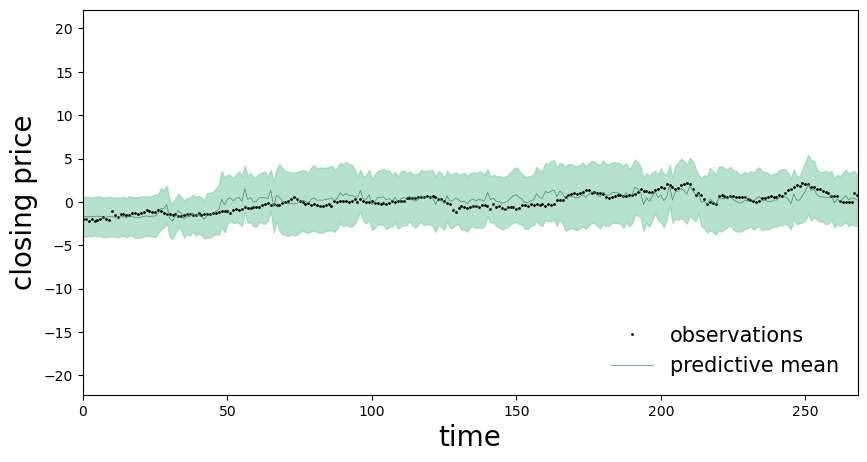

In [20]:
predictive = Predictive(model_VI, guide=guide, num_samples=1000)

preds = predictive(X_pre_n_tensor)

plot_predictions(preds, y_pre_n_tensor)

In [21]:
pred_samples = preds["obs"]
pred_mean = pred_samples.mean(dim=0) 
# Calculate RMSE
y_true = y_pre_n_tensor
rmse = torch.sqrt(torch.mean((pred_mean - y_true) ** 2))
print(rmse)

tensor(0.6988)


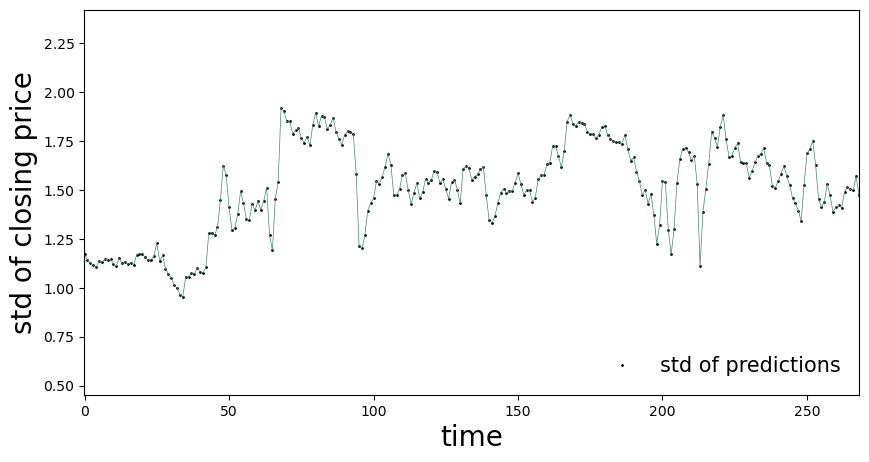

In [22]:
plot_uncertainty(preds, y_pre_n)

### 4. uncertainty quantification of data post GDPR

#### 4.1 Train the prior of BNN.

In [23]:
noise_var = 0.1
n_units = 128
n_hidden = 1
activation_fn = "tanh"
num_iters = 300  # Number of iteterations of Wasserstein optimization
lr = 0.05        # The learning rate
n_samples = 128  # The mini-batch size
out_dir = "./exp/gdpr/optim_gaussian"

X_post_n, y_post_n, y_mean, y_std = normalize_data(X_post, y_post)
x_min, x_max = get_input_range(X_post_n, X_post_n)
epsilon = 1e-6
x_min = np.minimum(x_min, x_max - epsilon)
input_dim, output_dim = int(X_post.shape[-1]), 1
    
# Initialize the measurement set generator
rand_generator = MeasureSetGenerator(X_post_n, x_min, x_max, 0.7)
    
# Initialize the mean and covariance function of the target hierarchical GP prior
mean = mean_functions.Zero()
    
lengthscale = math.sqrt(2. * input_dim)
variance = 1.
kernel = kernels.RBF(input_dim=input_dim,
                     lengthscales=torch.tensor([lengthscale], dtype=torch.double),
                     variance=torch.tensor([variance], dtype=torch.double), ARD=True)

# Place hyper-priors on lengthscales and variances
kernel.lengthscales.prior = priors.LogNormal(
    torch.ones([input_dim]) * math.log(lengthscale),
    torch.ones([input_dim]) * 1.)
kernel.variance.prior = priors.LogNormal(
    torch.ones([1]) * 0.1,
    torch.ones([1]) * 1.)
        
# Initialize the GP model
gp = GPR(X=torch.from_numpy(X_post_n), Y=torch.from_numpy(y_post_n).reshape([-1, 1]),
             kern=kernel, mean_function=mean)
gp.likelihood.variance.set(noise_var)
    
# Initialize tunable MLP prior
hidden_dims = [n_units] * n_hidden
mlp_reparam = GaussianMLPReparameterization(input_dim, output_dim,
    hidden_dims, activation_fn, scaled_variance=True)
    
mapper = MapperWasserstein(gp, mlp_reparam, rand_generator, out_dir=out_dir,
                               output_dim=output_dim, n_data=100,
                               wasserstein_steps=(0, 300), ##Should be more than 200
                               wasserstein_lr=0.02,
                               logger=None, wasserstein_thres=0.1,
                               n_gpu=1, gpu_gp=True) ##Change GPU if you don't have CUDA; same thing for the PRE training
    
w_hist = mapper.optimize(num_iters=num_iters, n_samples=n_samples,
                             lr=lr, print_every=10, save_ckpt_every=10, debug=True)

print("----" * 20)

C:\Users\thumo\OneDrive - Georgia Institute of Technology\Georgia Tech\Semesters\Spring 2025\CSE 8803 IUQ\Project\2-BNN_trained_prior\you-need-a-good-prior\optbnn\gp\parameter.py:63: UserWarning: An output with one or more elements was resized since it had shape [1], which does not match the required output shape []. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Resize.cpp:37.)
  return torch.log(torch.exp(t) - 1, out=out)


>>> Iteration #   1: Wasserstein Dist 7.1260
>>> Iteration #  10: Wasserstein Dist 2.0969
>>> Iteration #  20: Wasserstein Dist 2.4995
>>> Iteration #  30: Wasserstein Dist 2.0274
>>> Iteration #  40: Wasserstein Dist 2.2206
>>> Iteration #  50: Wasserstein Dist 0.8961
>>> Iteration #  60: Wasserstein Dist 1.2512
>>> Iteration #  70: Wasserstein Dist 1.9699
>>> Iteration #  80: Wasserstein Dist 0.5000
>>> Iteration #  90: Wasserstein Dist 2.3366
>>> Iteration # 100: Wasserstein Dist 1.0332
>>> Iteration # 110: Wasserstein Dist -0.2722
>>> Iteration # 120: Wasserstein Dist 0.2834
>>> Iteration # 130: Wasserstein Dist 0.5944
>>> Iteration # 140: Wasserstein Dist 1.0303
>>> Iteration # 150: Wasserstein Dist 1.3663
>>> Iteration # 160: Wasserstein Dist 1.8349
>>> Iteration # 170: Wasserstein Dist 1.5051
>>> Iteration # 180: Wasserstein Dist 0.9981
>>> Iteration # 190: Wasserstein Dist 1.4384
>>> Iteration # 200: Wasserstein Dist 0.4468
>>> Iteration # 210: Wasserstein Dist -0.0811
>>> Iter

In [24]:
for name, param in mlp_reparam.named_parameters():
    print(f"parameter name: {name}, parameter shape: {param}")

parameter name: layers.0.W_std, parameter shape: Parameter containing:
tensor([3.5187], device='cuda:0', requires_grad=True)
parameter name: layers.0.b_std, parameter shape: Parameter containing:
tensor([2.4002], device='cuda:0', requires_grad=True)
parameter name: output_layer.W_std, parameter shape: Parameter containing:
tensor([1.0891], device='cuda:0', requires_grad=True)
parameter name: output_layer.b_std, parameter shape: Parameter containing:
tensor([-1.1970], device='cuda:0', requires_grad=True)


In [25]:
def maintain_positivity(x):
    '''
    maintain the positivity of weight and bias standard derivations
    '''
    return np.log(1 + np.exp(x))

post_weight_prior = [maintain_positivity(3.1053), maintain_positivity(1.1434)]
post_bias_prior = [maintain_positivity(2.0997), maintain_positivity(-0.6430)]

#### 4.2 train the BNN

In [26]:
# clear parameters to ensure every training start from scratch
pyro.clear_param_store()

# set up BNN
model_VI = BNN(post_weight_prior, post_bias_prior, in_dim=25, out_dim=1, hid_dim=128, n_hid_layers=1)

#mean_field_guide = AutoDiagonalNormal(model_VI) # mean field variational inference
guide = AutoMultivariateNormal(model_VI) # use multivariate normal with full covariance to approxiamte posterior

# apply SGD to maximizing the ELBO
optimizer = pyro.optim.Adam({"lr": 0.001})
svi = SVI(model_VI, guide, optimizer, loss=Trace_ELBO())

# # clear parameters to avoid influencing others
pyro.clear_param_store()

In [27]:
num_epochs = 12000 # number of training epoches, 10000 now for quick test
progress_bar = trange(num_epochs) # show progress bar (only for visualization purpose)

X_post_n_tensor = torch.tensor(X_post_n, dtype=torch.float)
y_post_n_tensor = torch.tensor(y_post_n, dtype=torch.float)

for epoch in progress_bar:
    loss = svi.step(X_post_n_tensor, y_post_n_tensor)
    progress_bar.set_postfix(loss=f"{loss / X_post_n.shape[0]:.3f}")
    if epoch % 100 == 0:
        print("[iteration %04d] loss: %.3f" % (epoch + 1, loss / X_post_n.shape[0]))

  0%|          | 0/12000 [00:00<?, ?it/s]

[iteration 0001] loss: 823.247
[iteration 0101] loss: 2550.743
[iteration 0201] loss: 60.338
[iteration 0301] loss: 326.256
[iteration 0401] loss: 646.652
[iteration 0501] loss: 786.150
[iteration 0601] loss: 112.265
[iteration 0701] loss: 166.769
[iteration 0801] loss: 45.417
[iteration 0901] loss: 466.688
[iteration 1001] loss: 83.184
[iteration 1101] loss: 50.188
[iteration 1201] loss: 54.424
[iteration 1301] loss: 106.513
[iteration 1401] loss: 114.745
[iteration 1501] loss: 240.736
[iteration 1601] loss: 71.496
[iteration 1701] loss: 23.449
[iteration 1801] loss: 82.637
[iteration 1901] loss: 163.349
[iteration 2001] loss: 24.285
[iteration 2101] loss: 40.981
[iteration 2201] loss: 27.326
[iteration 2301] loss: 75.549
[iteration 2401] loss: 185.906
[iteration 2501] loss: 26.189
[iteration 2601] loss: 29.369
[iteration 2701] loss: 51.682
[iteration 2801] loss: 35.220
[iteration 2901] loss: 130.207
[iteration 3001] loss: 38.450
[iteration 3101] loss: 40.947
[iteration 3201] loss: 41

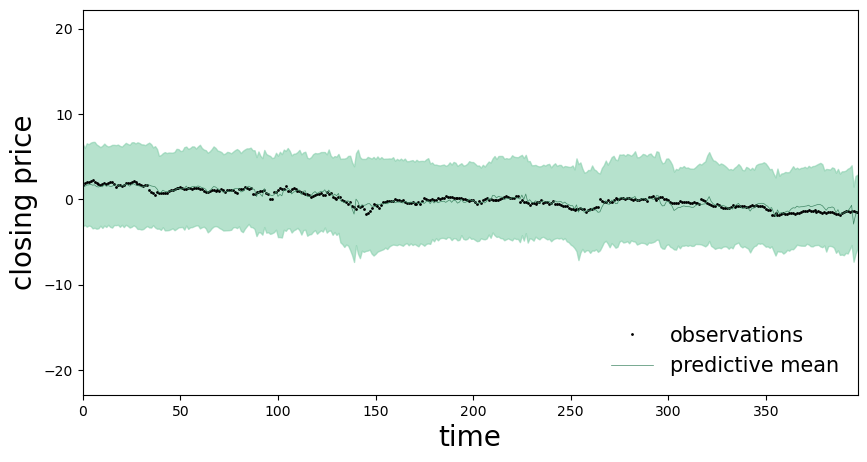

In [28]:
predictive = Predictive(model_VI, guide=guide, num_samples=1000)

preds = predictive(X_post_n_tensor)

plot_predictions(preds, y_post_n_tensor)

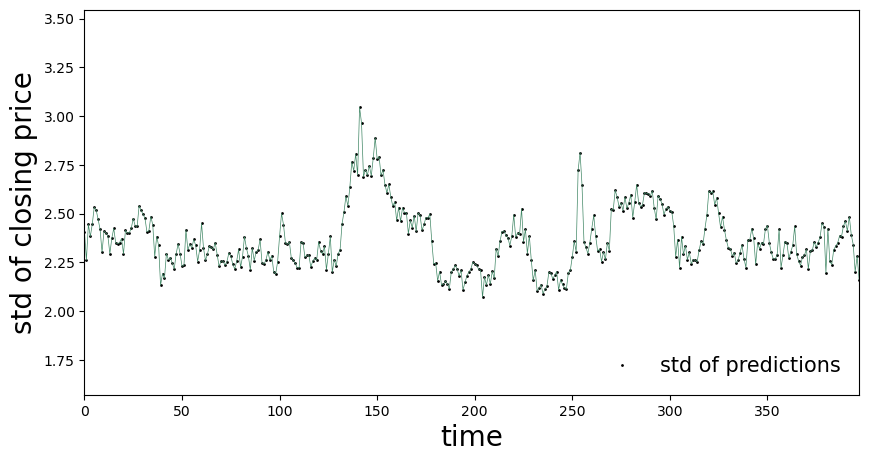

In [29]:
plot_uncertainty(preds, y_post_n)

In [30]:
##RMSE
pred_samples = preds["obs"]
pred_mean = pred_samples.mean(dim=0) 
# Calculate RMSE
y_true = y_post_n_tensor
rmse = torch.sqrt(torch.mean((pred_mean - y_true) ** 2))
print(rmse)

tensor(0.3954)
